# Qwen3.5-0.8B — Zero-shot vs. LoRA Fine-tuned Product Classification




In [1]:
!nvidia-smi

Mon Jul 20 23:30:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:

# ============ CONFIG — bump these back up later ============
N_PER_CLASS   = 660     #  250*16
TEST_SIZE     = 1000
TRAIN_EPOCHS  = 1
MODEL_NAME    = "Qwen/Qwen3.5-0.8B"
MAX_LEN       = 512
SEED          = 42


## 1. Install packages

In [3]:
!pip install -U "transformers>=4.57" accelerate peft trl datasets scikit-learn pandas matplotlib seaborn psycopg2-binary
# Qwen3.5 is a very recent architecture. If AutoModelForCausalLM / AutoTokenizer complain
# they don't recognize "qwen3_5", uncomment the line below to install transformers from source:
# !pip install -U "transformers @ git+https://github.com/huggingface/transformers.git"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 123.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.2/863.2 kB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 89.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 121.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 103.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 100.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 12.7 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: scikit-learn
    Foun

In [3]:
!nvidia-smi

Mon Jul 20 23:31:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Mount Drive — for saving the adapter + results

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = "/content/drive/MyDrive/shopping_assistant_qwen_lora"
OUTPUT_DIR = f"{PROJECT_DIR}/outputs/qwen3.5-0.8b-main-category-lora"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(PROJECT_DIR)


Mounted at /content/drive
/content/drive/MyDrive/shopping_assistant_qwen_lora


## 3. Connect to the shared DB and pull a balanced sample

In [6]:
import os


os.environ["DB_HOST"] = "134.122.33.127"
os.environ["DB_PORT"] = "5432"
os.environ["DB_NAME"] = "amazon_products"
os.environ["DB_USER"] = "amazon_user"
os.environ["DB_PASSWORD"] = "Mevisw7St5XExL?rlz9T"


In [7]:
import psycopg2

def get_connection():
    return psycopg2.connect(
        host=os.environ["DB_HOST"],
        port=os.environ["DB_PORT"],
        dbname=os.environ["DB_NAME"],
        user=os.environ["DB_USER"],
        password=os.environ["DB_PASSWORD"],
    )

conn = get_connection()
cur = conn.cursor()
cur.execute("SELECT 1;")
print(cur.fetchone())
cur.close()
conn.close()


(1,)


In [8]:
import pandas as pd

# Stratified sample: up to N_PER_CLASS rows per main_category, pulled server-side
SAMPLE_SQL = """
WITH ranked AS (
    SELECT
        title,
        main_category,
        ROW_NUMBER() OVER (PARTITION BY main_category ORDER BY RANDOM()) AS rn
    FROM amazon_products
    WHERE title IS NOT NULL
      AND main_category IS NOT NULL
      AND TRIM(title) <> ''
)
SELECT title, main_category
FROM ranked
WHERE rn <= %s;
"""

conn = get_connection()
df_raw = pd.read_sql(SAMPLE_SQL, conn, params=(N_PER_CLASS,))
conn.close()

print(df_raw.shape)
print(df_raw["main_category"].value_counts())


/tmp/ipykernel_1389/773908479.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_raw = pd.read_sql(SAMPLE_SQL, conn, params=(N_PER_CLASS,))


(10039, 2)
main_category
Arts, Crafts & Party Supplies    660
Automotive                       660
Baby Products                    660
Beauty & Personal Care           660
Electronics & Computers          660
Fashion, Shoes & Luggage         660
Health & Household               660
Home & Kitchen                   660
Industrial & Scientific          660
Pet Supplies                     660
Smart Home                       660
Sports & Outdoors                660
Tools & Home Improvement         660
Toys & Games                     660
Video Games                      660
Gift Cards                       139
Name: count, dtype: int64


## 4. Build train/test splits

In [9]:
from datasets import Dataset

INSTRUCTION = "Classify the product into one main category."

records = [
    {
        "instruction": INSTRUCTION,
        "input": f"Title: {row.title}",
        "output": row.main_category,
    }
    for row in df_raw.itertuples()
]

full_dataset = Dataset.from_list(records)

dataset = full_dataset.train_test_split(test_size=TEST_SIZE, seed=SEED)

dataset["train"] = dataset["train"].shuffle(seed=SEED)

label_list = sorted(set(full_dataset["output"]))
print(dataset)
print("Number of labels:", len(label_list))
print(label_list)


DatasetDict({
    train: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 9039
    })
    test: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 1000
    })
})
Number of labels: 16
['Arts, Crafts & Party Supplies', 'Automotive', 'Baby Products', 'Beauty & Personal Care', 'Electronics & Computers', 'Fashion, Shoes & Luggage', 'Gift Cards', 'Health & Household', 'Home & Kitchen', 'Industrial & Scientific', 'Pet Supplies', 'Smart Home', 'Sports & Outdoors', 'Tools & Home Improvement', 'Toys & Games', 'Video Games']


## 5. Load tokenizer + model (fp16 — required on T4)

In [10]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="auto",
    dtype=torch.float16,
    trust_remote_code=True,
)
model.config.use_cache = True  # True for generation; will flip to False before training


config.json:   0%|          | 0.00/2.91k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/6.72M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/3.35M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 12.8MB            

...

model.safetensors.index.json:   0%|          | 0.00/50.9k [00:00<?, ?B/s]

model.safetensors-00001-of-00001.safeten(…): reconstructing file:   0%|          |  0.00B / 1.75GB            

model.safetensors-00001-of-00001.safeten(…): downloading bytes:           |  0.00B            

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

## 6. Zero-shot evaluation

Uses Qwen's real chat template. The system/user prompt gives the model the full list
of allowed labels,
since the base model has never seen this label set.

In [11]:
import re

def clean_label(text):
    text = text.strip()
    text = text.split("\n")[0].strip()
    text = re.sub(r"^[\"'\s]+|[\"'\s]+$", "", text)
    text = text.replace("Answer:", "").strip()
    return text


def predict_category_zero_shot(title, model_, tokenizer_):
    labels_text = "\n".join(f"- {l}" for l in label_list)
    system_msg = (
        "You are a product classification assistant. "
        "Classify the product into exactly one category from the allowed label list. "
        "Output only the label text, nothing else."
    )
    user_msg = f"Allowed labels:\n{labels_text}\n\nProduct title:\n{title}"

    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": user_msg},
    ]
    prompt = tokenizer_.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer_(prompt, return_tensors="pt").to(model_.device)

    with torch.no_grad():
        outputs = model_.generate(
            **inputs,
            max_new_tokens=30,
            do_sample=False,
            pad_token_id=tokenizer_.eos_token_id,
        )

    generated = outputs[0][inputs["input_ids"].shape[1]:]
    response = tokenizer_.decode(generated, skip_special_tokens=True)
    return response


# quick smoke test
print(predict_category_zero_shot("Apple AirPods Pro Wireless Earbuds with Active Noise Cancellation", model, tokenizer))
print(predict_category_zero_shot("CeraVe Moisturizing Cream for Dry Skin", model, tokenizer))


Audio & Electronics

Beauty & Personal Care



In [12]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from tqdm.auto import tqdm

y_true_zs, y_pred_zs = [], []

for ex in tqdm(dataset["test"], desc="Zero-shot eval"):
    title = ex["input"].replace("Title:", "").strip()
    true_label = ex["output"].strip()

    pred_label = clean_label(predict_category_zero_shot(title, model, tokenizer))

    y_true_zs.append(true_label)
    y_pred_zs.append(pred_label)

acc_zs = accuracy_score(y_true_zs, y_pred_zs)
macro_f1_zs = f1_score(y_true_zs, y_pred_zs, average="macro")
weighted_f1_zs = f1_score(y_true_zs, y_pred_zs, average="weighted")

print("Accuracy:", acc_zs)
print("Macro F1:", macro_f1_zs)
print("Weighted F1:", weighted_f1_zs)
print(classification_report(y_true_zs, y_pred_zs, labels=label_list, zero_division=0))


Zero-shot eval:   0%|          | 0/1000 [00:00<?, ?it/s]

Accuracy: 0.327
Macro F1: 0.2008860642698275
Weighted F1: 0.31905546055283457
                               precision    recall  f1-score   support

Arts, Crafts & Party Supplies       0.50      0.02      0.03        65
                   Automotive       1.00      0.05      0.10        59
                Baby Products       0.78      0.42      0.55        69
       Beauty & Personal Care       0.79      0.27      0.40        71
      Electronics & Computers       0.33      0.02      0.03        65
     Fashion, Shoes & Luggage       0.77      0.43      0.56        69
                   Gift Cards       0.55      1.00      0.71        16
           Health & Household       0.35      0.48      0.41        62
               Home & Kitchen       0.20      0.64      0.30        74
      Industrial & Scientific       0.00      0.00      0.00        49
                 Pet Supplies       1.00      0.04      0.09        67
                   Smart Home       1.00      0.20      0.33        5

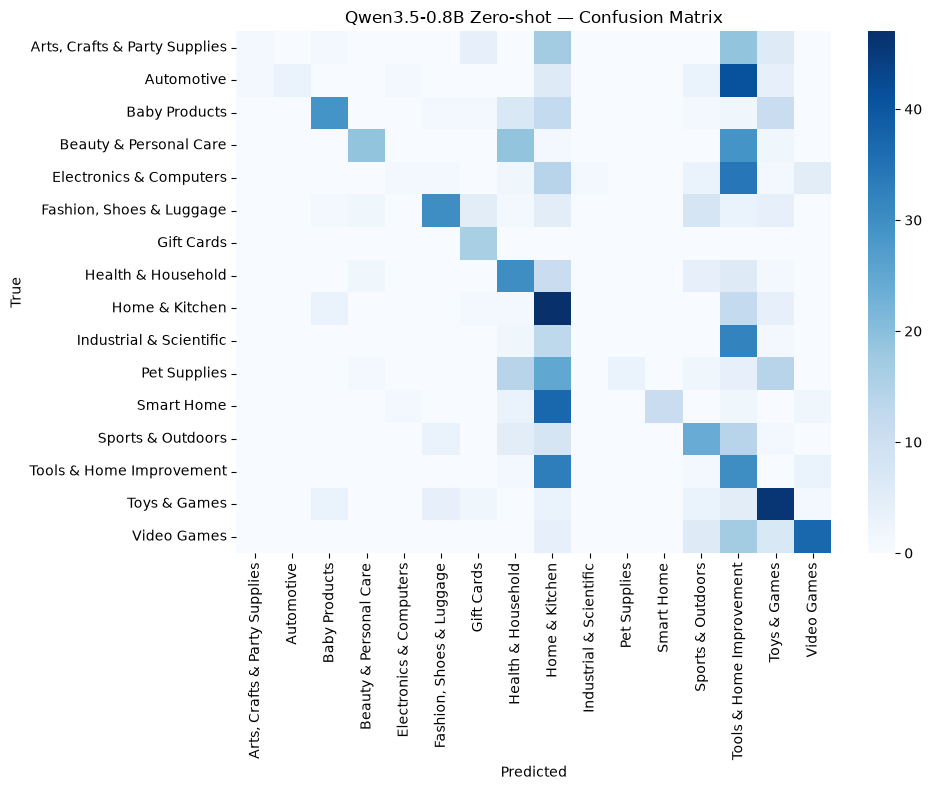

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, xticklabels=labels, yticklabels=labels, cmap="Blues", annot=False)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_confusion(y_true_zs, y_pred_zs, label_list, "Qwen3.5-0.8B Zero-shot — Confusion Matrix")


## 7. Format training data + LoRA fine-tune

the model learns the label set
from the data itself.

In [14]:
def format_example(example):
    messages = [
        {"role": "system", "content": "You are a product classification assistant. Classify the product into exactly one main category. Output only the category label."},
        {"role": "user", "content": f"{example['instruction']}\n{example['input']}"},
        {"role": "assistant", "content": example["output"]},
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
    return {"text": text}

dataset = dataset.map(format_example)
print(dataset["train"][0]["text"])


Map:   0%|          | 0/9039 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

<|im_start|>system
You are a product classification assistant. Classify the product into exactly one main category. Output only the category label.<|im_end|>
<|im_start|>user
Classify the product into one main category.
Title: Cella's Chocolate Cherry Flavored Coffee, Compatible With 2.0 Keurig K Cup Brewers, 40 Count (Pack of 1)<|im_end|>
<|im_start|>assistant
<think>

</think>

Home & Kitchen<|im_end|>



In [15]:
from peft import LoraConfig

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules="all-linear",
)


In [16]:
!pip install --upgrade torchao peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 46.5 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [17]:
model.config.use_cache = False  # required for training

from trl import SFTTrainer, SFTConfig

sft_config = SFTConfig(
    output_dir=OUTPUT_DIR,

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,

    learning_rate=2e-4,
    num_train_epochs=TRAIN_EPOCHS,

    logging_steps=20,
    eval_strategy="steps",
    eval_steps=100,
    save_steps=100,
    save_total_limit=2,

    fp16=True,       # NOT bf16 — T4 has no bf16 tensor cores
    optim="adamw_torch",
    report_to="none",
    gradient_checkpointing=False,

    dataset_text_field="text",
    max_length=MAX_LEN,
    packing=False,
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    peft_config=lora_config,
    processing_class=tokenizer,
)

trainer.train()
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)


Adding EOS to train dataset:   0%|          | 0/9039 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/9039 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/9039 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/9039 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

...

Building labels for eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046, 'pad_token_id': 248044}.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
100,1.487003,1.437802,1.393342,147966.000000,0.745944
200,1.458172,1.408824,1.407058,295764.000000,0.749525
300,1.433930,1.393967,1.410033,443918.000000,0.751035
400,1.410633,1.377733,1.383811,592100.000000,0.753006
500,1.361539,1.369347,1.388488,739719.000000,0.754220
565,1.396958,1.366127,1.381434,835676.000000,0.754821


('/content/drive/MyDrive/shopping_assistant_qwen_lora/outputs/qwen3.5-0.8b-main-category-lora/tokenizer_config.json',
 '/content/drive/MyDrive/shopping_assistant_qwen_lora/outputs/qwen3.5-0.8b-main-category-lora/chat_template.jinja',
 '/content/drive/MyDrive/shopping_assistant_qwen_lora/outputs/qwen3.5-0.8b-main-category-lora/tokenizer.json')

## 8. Fine-tuned evaluation

In [18]:
model.config.use_cache = True

def predict_category_finetuned(title, model_, tokenizer_):
    messages = [
        {"role": "system", "content": "You are a product classification assistant. Classify the product into exactly one main category. Output only the category label."},
        {"role": "user", "content": f"Classify the product into one main category.\nTitle: {title}"},
    ]
    prompt = tokenizer_.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer_(prompt, return_tensors="pt").to(model_.device)

    with torch.no_grad():
        outputs = model_.generate(
            **inputs,
            max_new_tokens=30,
            do_sample=False,
            pad_token_id=tokenizer_.eos_token_id,
        )

    generated = outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer_.decode(generated, skip_special_tokens=True)


y_true_ft, y_pred_ft = [], []

for ex in tqdm(dataset["test"], desc="Fine-tuned eval"):
    title = ex["input"].replace("Title:", "").strip()
    true_label = ex["output"].strip()

    pred_label = clean_label(predict_category_finetuned(title, model, tokenizer))

    y_true_ft.append(true_label)
    y_pred_ft.append(pred_label)

acc_ft = accuracy_score(y_true_ft, y_pred_ft)
macro_f1_ft = f1_score(y_true_ft, y_pred_ft, average="macro")
weighted_f1_ft = f1_score(y_true_ft, y_pred_ft, average="weighted")

print("Accuracy:", acc_ft)
print("Macro F1:", macro_f1_ft)
print("Weighted F1:", weighted_f1_ft)
print(classification_report(y_true_ft, y_pred_ft, labels=label_list, zero_division=0))


Fine-tuned eval:   0%|          | 0/1000 [00:00<?, ?it/s]

Accuracy: 0.753
Macro F1: 0.7574695789182978
Weighted F1: 0.7525455888284944
                               precision    recall  f1-score   support

Arts, Crafts & Party Supplies       0.68      0.82      0.74        65
                   Automotive       0.73      0.69      0.71        59
                Baby Products       0.87      0.80      0.83        69
       Beauty & Personal Care       0.92      0.92      0.92        71
      Electronics & Computers       0.79      0.83      0.81        65
     Fashion, Shoes & Luggage       0.76      0.78      0.77        69
                   Gift Cards       1.00      0.94      0.97        16
           Health & Household       0.69      0.61      0.65        62
               Home & Kitchen       0.61      0.62      0.61        74
      Industrial & Scientific       0.43      0.57      0.49        49
                 Pet Supplies       0.97      0.87      0.91        67
                   Smart Home       0.94      0.91      0.93        56

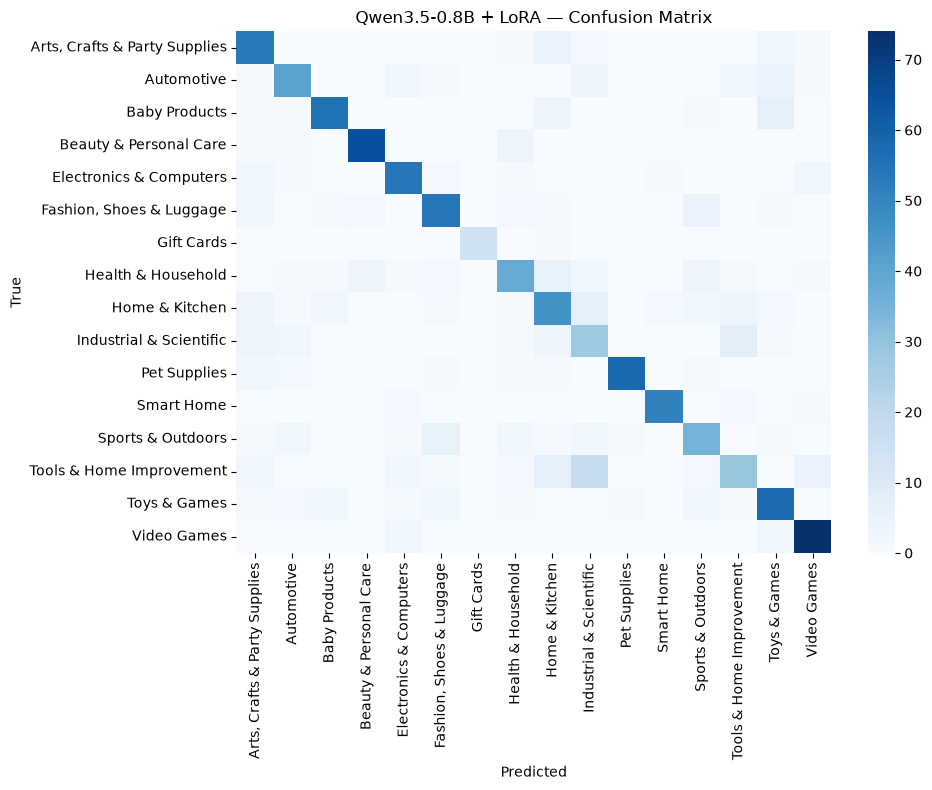

In [19]:
plot_confusion(y_true_ft, y_pred_ft, label_list, "Qwen3.5-0.8B + LoRA — Confusion Matrix")

## 9. Zero-shot vs. fine-tuned comparison

In [20]:
comparison_df = pd.DataFrame([
    {
        "Model": "Qwen3.5-0.8B Zero-shot",
        "Accuracy": acc_zs,
        "Macro F1": macro_f1_zs,
        "Weighted F1": weighted_f1_zs,
    },
    {
        "Model": "Qwen3.5-0.8B + LoRA",
        "Accuracy": acc_ft,
        "Macro F1": macro_f1_ft,
        "Weighted F1": weighted_f1_ft,
    },
])

display(comparison_df)

comparison_df.to_csv(f"{PROJECT_DIR}/qwen_lora_vs_zeroshot_results.csv", index=False)
print("Saved comparison results to:", f"{PROJECT_DIR}/qwen_lora_vs_zeroshot_results.csv")


,Model,Accuracy,Macro F1,Weighted F1
0,Qwen3.5-0.8B Zero-shot,0.327,0.200886,0.319055
1,Qwen3.5-0.8B + LoRA,0.753,0.757470,0.752546


Saved comparison results to: /content/drive/MyDrive/shopping_assistant_qwen_lora/qwen_lora_vs_zeroshot_results.csv


## 10. Sanity check — any predictions outside the allowed label set?

In [21]:
allowed_labels = set(label_list)
invalid_zs = sorted(set(y_pred_zs) - allowed_labels)
invalid_ft = sorted(set(y_pred_ft) - allowed_labels)

print("Invalid zero-shot labels:", len(invalid_zs), invalid_zs[:20])
print("Invalid fine-tuned labels:", len(invalid_ft), invalid_ft[:20])


Invalid zero-shot labels: 10 ['Art Supplies', 'Art and Crafts', 'Art, Crafts & Party Supplies', 'Art, Toys & Games', 'Artistic Decor', 'Audio', 'Crime Thriller', 'Fish Feeding Ring with Powerful Magnet, Aquarium Feeding Ring, Frozen Fish Food Feeder for Fish Tank', 'Gaming', 'Travel Luggage Cover']
Invalid fine-tuned labels: 0 []
